# Setup

In [3]:
# main
import re
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from statsmodels.distributions.empirical_distribution import ECDF
from statsmodels.tsa.filters.hp_filter import hpfilter

# models and algorithms
from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize

# diagnostics
from sklearn.metrics import mean_squared_error

# charts
import matplotlib.pyplot as plt

# preprocessing
from sklearn.base import BaseEstimator, TransformerMixin

In [4]:
# Custom transformer to scale and return DataFrame
class MinMaxScalerDF(BaseEstimator, TransformerMixin):

    def __init__(self, feature_range=(0, 1)):
        self.feature_range = feature_range

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        min_new, max_new = self.feature_range
        X_std = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
        scaled_data = X_std * (max_new - min_new) + min_new
        return scaled_data

In [5]:
def ecdf_normalize(x):
    x = x.sort_values().copy()
    x_ecdf = ECDF(x).y[1:]
    return pd.Series(x_ecdf, index=x.index).sort_index()

In [6]:
def cdf_kde(x, kde):
    return kde.integrate_box(-np.inf, x)


def kde_normalize(x):
    x = x.sort_values().copy()
    kde = gaussian_kde(x)
    cdf = np.array([cdf_kde(v, kde) for v in x])
    return pd.Series(cdf, index=x.index).sort_index()

In [7]:
def ewma(S, Cov0, lam=0.94, med=0.5):
    S_st = S - med
    SS = np.einsum('ij,ik->ijk', S_st, S_st)
    Cov = np.zeros(SS.shape)
    Cov[0] = Cov0

    # cov estimation
    for i in range(1, SS.shape[0]):
        Cov[i] = lam * Cov[i-1] + (1-lam) * SS[i]
    sigma2 = np.diagonal(Cov, axis1=1, axis2=2)
    sig_sig = np.einsum('ij,ik->ijk', np.sqrt(sigma2), np.sqrt(sigma2))

    # corr estimation
    Corr = Cov / sig_sig
    tl_indices = np.tril_indices(S_st.shape[1], k=-1)
    Corr_series = pd.DataFrame(Corr[:, tl_indices[0], tl_indices[1]], index=S_st.index)
    return Corr, Corr_series

In [8]:
model = LinearRegression(fit_intercept=True)


def weight_loss(w, S, Corr, Y):
    fcyi = np.einsum('ij,ijk,ik->i', w * S, Corr, w * S).reshape(-1, 1)
    res = model.fit(fcyi, Y)
    Y_pred = res.predict(fcyi)
    rmse = np.sqrt(mean_squared_error(Y, Y_pred))
    return rmse


def weight_optimization(S, Corr, Y):
    index = Y.index.intersection(S.index)
    S = S.loc[index].sort_index().copy()
    Y = Y.loc[index].sort_index().copy()
    w_init = np.ones(S.shape[1])/S.shape[1]

    # Constraint: sum(w) = 1
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}

    # Bounds for weights: each weight should be between 0 and 1
    bounds = [(0, 1) for _ in range(S.shape[1])]

    # ptimization goes here
    result = minimize(weight_loss, w_init, args=(S, Corr, Y), method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x

# KDE normalization

In [9]:
col_order = [
    'Consumer stock diff', 'Mortgage stock diff', 'Corporate stock diff',
    'Property prices y-o-y growt rate', 'Total loans/GDP Y-o-Y',
    'Credit to GDP GAP', 'Trade account deficit/GDP',
    'Credit spread: households', 'Credit spread: non-financial corporations'
]
# series
FCyI_data_raw = pd.read_excel('Armenia_data_initial.xlsx', sheet_name='data', index_col=0, parse_dates=['Date'])
FCyI_data_raw = FCyI_data_raw[col_order].copy()
FCyI_data_raw.index = FCyI_data_raw.index.to_period('M').to_timestamp('M')

# target
Y = pd.read_excel('Armenia_data_initial.xlsx', sheet_name='Y', index_col=0, parse_dates=['Date']).squeeze()
Y.index = Y.index.to_period('M').to_timestamp('M')
# Y = pd.read_excel('Armenia_data.xlsx', sheet_name='Y', index_col=0, parse_dates=['Date']).squeeze()

# other
FCyI_data_stata = pd.read_excel('Armenia_data.xlsx', sheet_name='data', index_col=0, parse_dates=['Date'])
FCyI_data_stata.index = FCyI_data_stata.index.to_period('M').to_timestamp('M')

# transformations
FCyI_data_ecdf = FCyI_data_raw.agg(ecdf_normalize)
FCyI_data_kde = FCyI_data_raw.agg(kde_normalize)

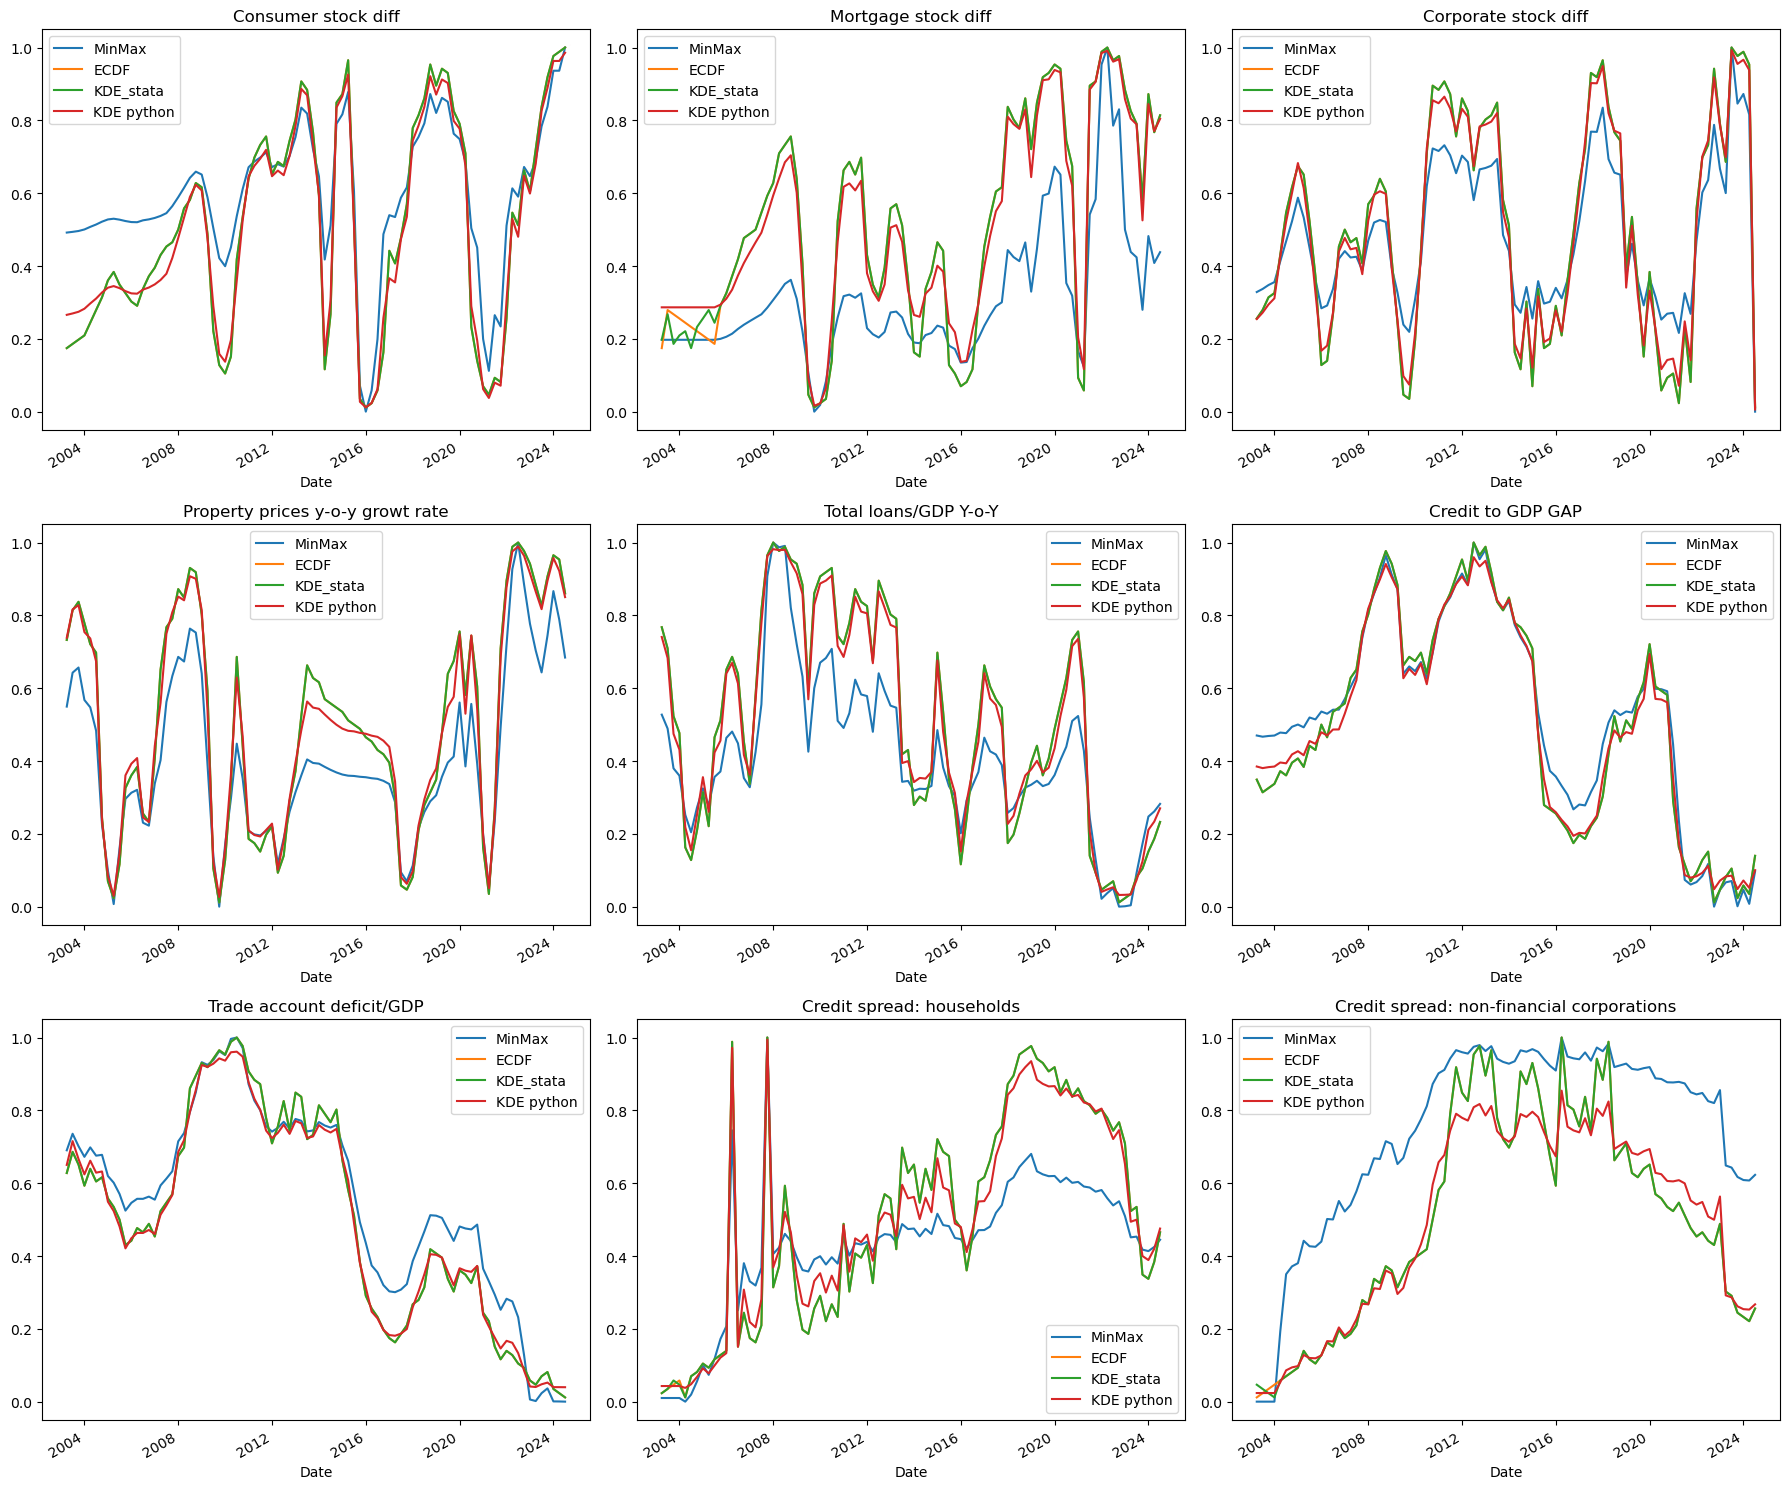

In [10]:
# Create a 3x3 grid of subplots
fig, axs = plt.subplots(3, 3, figsize=(18, 15))  # Adjust the figsize as needed
axs = axs.flatten()  # Flatten the array of subplots for easy indexing

for i, v in enumerate(FCyI_data_raw.columns):
    variable = v
    variable_stata = re.sub(r'[ /:-]', '', v)[:27]

    # Select the subplot in the grid
    ax = axs[i]

    mm = MinMaxScalerDF()
    mm_data = mm.fit_transform(FCyI_data_raw[[variable]])
    ax.plot(mm_data, label='MinMax')

    FCyI_data_ecdf[variable].plot(ax=ax, label='ECDF')
    FCyI_data_stata[variable_stata].plot(ax=ax, label='KDE_stata')
    FCyI_data_kde[variable].plot(ax=ax, label='KDE python')

    ax.legend()
    ax.set_title(f'{variable}')

plt.tight_layout()
plt.show()

# Finanical Cycle Index

In [11]:
# setup
# initial covariance
Cov0 = np.array([
    [0.0846, 0.0348, 0.0112, -0.0103, 0.0506, 0.0808, 0.0650, 0.0076, 0.0170],
    [0.0348, 0.0846, 0.0600, -0.0297, -0.0015, 0.0189, 0.0044, 0.0681, 0.0591],
    [0.0112, 0.0600, 0.0846, -0.0557, 0.0001, 0.0044, -0.0089, 0.0686, 0.0676],
    [-0.0103, -0.0297, -0.0557, 0.0846, -0.0077, -0.0152, -0.0175, -0.0387, -0.0593],
    [0.0506, -0.0015, 0.0001, -0.0077, 0.0846, 0.0536, 0.0475, -0.0082, 0.0000],
    [0.0808, 0.0189, 0.0044, -0.0152, 0.0536, 0.0846, 0.0694, -0.0045, 0.0138],
    [0.0650, 0.0044, -0.0089, -0.0175, 0.0475, 0.0694, 0.0846, -0.0157, -0.0003],
    [0.0076, 0.0681, 0.0686, -0.0387, -0.0082, -0.0045, -0.0157, 0.0846, 0.0668],
    [0.0170, 0.0591, 0.0676, -0.0593, 0.0000, 0.0138, -0.0003, 0.0668, 0.0846]
])

# weights
w = np.array([0.2, 0.2, 0.05, 0.086, 0.08, 0.26, 0.048, 0.046, 0.036])  # weights by paper

In [27]:
# input data
S_stata = FCyI_data_stata.copy()

# EWMA
Corr_stata, Corr_series = ewma(S_stata, Cov0, lam=0.94, med=0.5)

# finanical cycle index estimation
fcyi = np.einsum('ij,ijk,ik->i', w * S_stata, Corr_stata, w * S_stata)
# fcyi_full = np.einsum('ij,ijk,ik->i', w * S_stata, np.ones(Corr_stata.shape), w * S_stata)
fcyi_smooth_stata = hpfilter(fcyi, lamb=0.5)[1]

In [13]:
# FCyI ECDF
S_ecdf = FCyI_data_ecdf.copy()
Corr_ecdf, Corr_series = ewma(S_ecdf, Cov0, lam=0.94, med=0.5)
fcyi = np.einsum('ij,ijk,ik->i', w * S_ecdf, Corr_ecdf, w * S_ecdf)
fcyi_smooth_ecdf = hpfilter(fcyi, lamb=0.5)[1]

In [14]:
# FCyI KDE
S_kde = FCyI_data_kde.copy()
Corr_KDE, Corr_series = ewma(S_kde, Cov0, lam=0.94, med=0.5)
fcyi = np.einsum('ij,ijk,ik->i', w * S_kde, Corr_KDE, w * S_kde)
fcyi_smooth_kde = hpfilter(fcyi, lamb=0.5)[1]

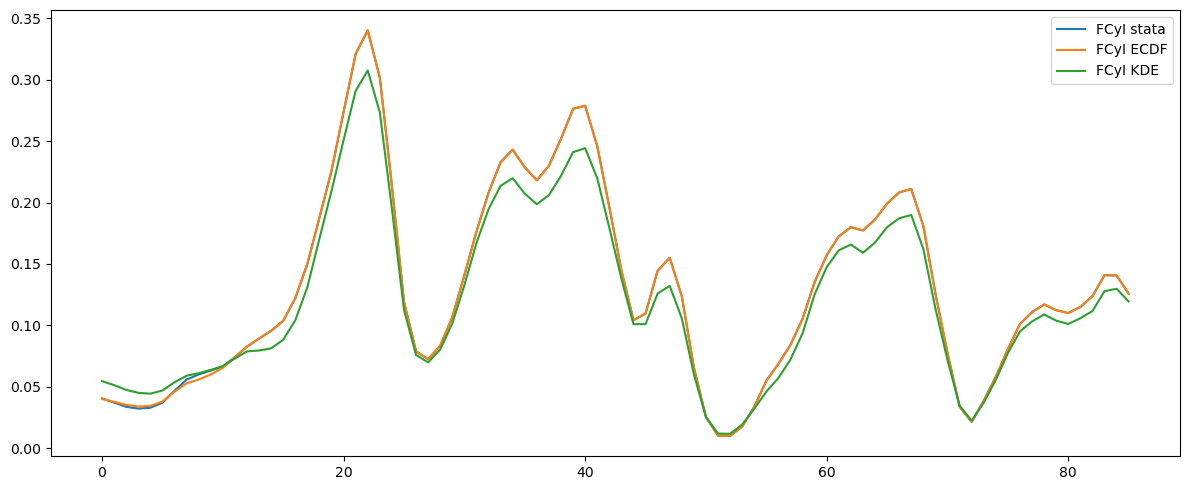

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
pd.Series(fcyi_smooth_stata).plot(ax=ax)
pd.Series(fcyi_smooth_ecdf).plot(ax=ax)
pd.Series(fcyi_smooth_kde).plot(ax=ax)
plt.legend(['FCyI stata', 'FCyI ECDF', 'FCyI KDE'])
plt.tight_layout()
plt.show()

In [16]:
# FCyI ECDF
# deriving the optimal w
Corr_ecdf, Corr_series = ewma(S_ecdf, np.array(S_ecdf.cov()), lam=0.94, med=0.5)
w_optimal = weight_optimization(S_ecdf, Corr_ecdf[:-1], Y)
fcyi = np.einsum('ij,ijk,ik->i', w_optimal * S_ecdf, Corr_ecdf, w_optimal * S_ecdf)
fcyi_smooth_ecdf_optimal = hpfilter(fcyi, lamb=0.5)[1]

In [17]:
# FCyI KDE
# deriving the optimal w
Corr_KDE, Corr_series = ewma(S_kde, np.array(S_kde.cov()), lam=0.94, med=0.5)
w_optimal = weight_optimization(S_kde, Corr_KDE[:-1], Y)
fcyi = np.einsum('ij,ijk,ik->i', w_optimal * S_kde, Corr_KDE, w_optimal * S_kde)
fcyi_smooth_kde_optimal = hpfilter(fcyi, lamb=0.5)[1]

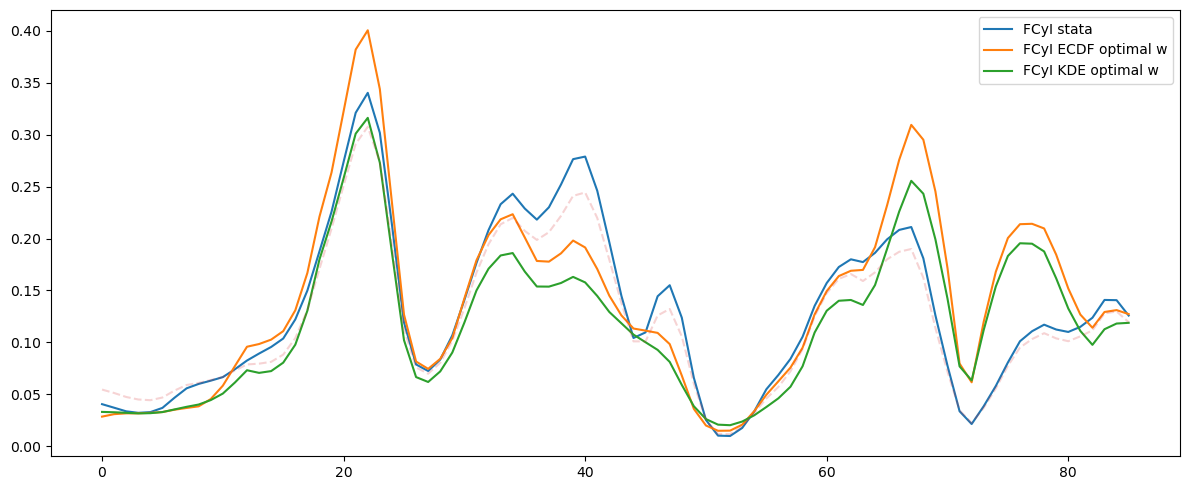

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))
pd.Series(fcyi_smooth_stata).plot(ax=ax)
pd.Series(fcyi_smooth_ecdf_optimal).plot(ax=ax)
pd.Series(fcyi_smooth_kde_optimal).plot(ax=ax)
pd.Series(fcyi_smooth_kde).plot(linestyle='dashed', alpha=0.2, ax=ax)
plt.legend(['FCyI stata', 'FCyI ECDF optimal w', 'FCyI KDE optimal w'])
plt.tight_layout()
plt.show()